# Supervised Learning Models and Metrics

In [1]:
from util.met_cleaning import clean_met_data
from util.preprocessing import supervised_preprocessing
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, make_scorer, confusion_matrix, ConfusionMatrixDisplay, PrecisionRecallDisplay
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
import matplotlib.pyplot as plt
from joblib import load#, dump

In [2]:
df = clean_met_data()

In [3]:
X_train, X_test, y_train, y_test, X_train_resampled, y_train_resampled = supervised_preprocessing(df)

## Importing saved models to cut down runtime - the files are too big to upload to github

In [ ]:
# comment this cell out if not importing models from files

# rfc_cw = load('../models/supervised/exploration/rfc_cw.pkl.lzma')
# rfc_smote = load('../models/supervised/exploration/rfc_smote.pkl.lzma')
# rfc_und = load('../models/supervised/exploration/rfc_und.pkl.lzma')

# rfc_cw_search = load('../models/supervised/tuning/rfc_cw_search.pkl.lzma')
# rfc_smote_search = load('../models/supervised/tuning/rfc_smote_search.pkl.lzma')

## Class Weighting

In [ ]:
# comment this cell out if importing model from pkl file

rfc_cw = RandomForestClassifier(class_weight='balanced', random_state=42).fit(X_train, y_train)

# dump(rfc_cw, '../models/supervised/exploration/rfc_cw.pkl.lzma')

*runtime: 117m 31.2s*

In [6]:
print("Training Data (RFC class weighting): ")
rfc_cw_pred_train = rfc_cw.predict(X_train)
print(f"Score: {rfc_cw.score(X_train, y_train)}")
print(f"Precision: {precision_score(y_train, rfc_cw_pred_train)}")
print(f"Recall: {recall_score(y_train, rfc_cw_pred_train)}")
print(f"F1 Score: {f1_score(y_train, rfc_cw_pred_train)}")
print(f"PR AUC Score: {average_precision_score(y_train, rfc_cw_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_train, rfc_cw_pred_train)}")
print()
print("Test Data (RFC class weighting): ")
rfc_cw_pred_test = rfc_cw.predict(X_test)
print(f"Score: {rfc_cw.score(X_test, y_test)}")
print(f"Precision: {precision_score(y_test, rfc_cw_pred_test, average='macro')}")
print(f"Recall: {recall_score(y_test, rfc_cw_pred_test, average='macro')}")
print(f"F1 Score: {f1_score(y_test, rfc_cw_pred_test, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_train, rfc_cw_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, rfc_cw_pred_test)}")

Training Data (RFC class weighting): 
Score: 0.9986003856027879
Precision: 0.9334755867955316
Recall: 0.998255033557047
F1 Score: 0.9647791399104885
PR AUC Score: 0.9318802114849108
ROC AUC Score: 0.9984310903658291

Test Data (RFC class weighting): 
Score: 0.9802767238535137
Precision: 0.7512972872075661
Recall: 0.5737788579402339
F1 Score: 0.6116382015423878
PR AUC Score: 0.9318802114849108
ROC AUC Score: 0.5737788579402338


In [7]:
lr_cw = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42).fit(X_train, y_train)

In [8]:
print("Training Data (LR class weighting): ")
lr_cw_pred_train = lr_cw.predict(X_train)
print(f"Score: {lr_cw.score(X_train, y_train)}")
print(f"Precision: {precision_score(y_train, lr_cw_pred_train, average='macro')}")
print(f"Recall: {recall_score(y_train, lr_cw_pred_train, average='macro')}")
print(f"F1 Score: {f1_score(y_train, lr_cw_pred_train, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_train, lr_cw_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_train, lr_cw_pred_train)}")
print()
print("Test Data (LR class weighting): ")
lr_cw_pred_test = lr_cw.predict(X_test)
print(f"Score: {lr_cw.score(X_test, y_test)}")
print(f"Precision: {precision_score(y_test, lr_cw_pred_test, average='macro')}")
print(f"Recall: {recall_score(y_test, lr_cw_pred_test, average='macro')}")
print(f"F1 Score: {f1_score(y_test, lr_cw_pred_test, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_train, lr_cw_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, lr_cw_pred_test)}")

Training Data (LR class weighting): 
Score: 0.8270561186089431
Precision: 0.5415975431369686
Recall: 0.8345199479912246
F1 Score: 0.5306045010601909
PR AUC Score: 0.07623654874709974
ROC AUC Score: 0.8345199479912246

Test Data (LR class weighting): 
Score: 0.82393393269548
Precision: 0.5373778803617439
Recall: 0.7896812925436633
F1 Score: 0.5238933005412237
PR AUC Score: 0.07623654874709974
ROC AUC Score: 0.7896812925436631


In [9]:
svm_cw = LinearSVC(class_weight='balanced', random_state=42).fit(X_train,y_train)

In [10]:
print("Training Data (SVM class weighting): ")
svm_cw_pred_train = svm_cw.predict(X_train)
print(f"Score: {svm_cw.score(X_train, y_train)}")
print(f"Precision: {precision_score(y_train, svm_cw_pred_train)}")
print(f"Recall: {recall_score(y_train, svm_cw_pred_train)}")
print(f"F1 Score: {f1_score(y_train, svm_cw_pred_train)}")
print(f"PR AUC Score: {average_precision_score(y_train, svm_cw_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_train, svm_cw_pred_train)}")
print()
print("Test Data (SVM class weighting): ")
svm_cw_pred_test = svm_cw.predict(X_test)
print(f"Score: {svm_cw.score(X_test, y_test)}")
print(f"Precision: {precision_score(y_test, svm_cw_pred_test, average='macro')}")
print(f"Recall: {recall_score(y_test, svm_cw_pred_test, average='macro')}")
print(f"F1 Score: {f1_score(y_test, svm_cw_pred_test, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_train, svm_cw_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, svm_cw_pred_test)}")

Training Data (SVM class weighting): 
Score: 0.9818075903949851
Precision: 0.9803921568627451
Recall: 0.053691275167785234
F1 Score: 0.10180707559175363
PR AUC Score: 0.0708102942015305
ROC AUC Score: 0.5268351254870972

Test Data (SVM class weighting): 
Score: 0.9811943253051798
Precision: 0.9861665774668099
Recall: 0.5289353084735586
F1 Score: 0.549935916138713
PR AUC Score: 0.0708102942015305
ROC AUC Score: 0.5289353084735586


## SMOTE

In [ ]:
# comment this cell out if importing model from pkl file

rfc_smote = RandomForestClassifier(random_state=42).fit(X_train_resampled, y_train_resampled)

# dump(rfc_smote, '../models/supervised/exploration/rfc_smote.pkl.lzma')

*runtime:* 129m 8.3s

In [12]:
print("Training Data (RFC smote): ")
rfc_smote_pred_train = rfc_smote.predict(X_train)
print(f"Score: {rfc_smote.score(X_train, y_train)}")
print(f"Precision: {precision_score(y_train, rfc_smote_pred_train)}")
print(f"Recall: {recall_score(y_train, rfc_smote_pred_train)}")
print(f"F1 Score: {f1_score(y_train, rfc_smote_pred_train)}")
print(f"PR AUC Score: {average_precision_score(y_train, rfc_smote_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_train, rfc_smote_pred_train)}")
print()
print("Test Data (RFC smote): ")
rfc_smote_pred_test = rfc_smote.predict(X_test)
print(f"Score: {rfc_smote.score(X_test, y_test)}")
print(f"Precision: {precision_score(y_test, rfc_smote_pred_test, average='macro')}")
print(f"Recall: {recall_score(y_test, rfc_smote_pred_test, average='macro')}")
print(f"F1 Score: {f1_score(y_test, rfc_smote_pred_test, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_train, rfc_smote_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, rfc_smote_pred_test)}")

Training Data (RFC smote): 
Score: 0.9994020063717252
Precision: 0.988362652232747
Recall: 0.9804026845637583
F1 Score: 0.984366576819407
PR AUC Score: 0.9693697211479557
ROC AUC Score: 0.9900883372413288

Test Data (RFC smote): 
Score: 0.9810396733751238
Precision: 0.7851259174436009
Recall: 0.5825216498008172
F1 Score: 0.6254758009008736
PR AUC Score: 0.9693697211479557
ROC AUC Score: 0.5825216498008171


In [13]:
lr_smote = LogisticRegression(random_state=42).fit(X_train_resampled, y_train_resampled)

In [14]:
print("Training Data (LR smote): ")
lr_smote_pred_train = lr_smote.predict(X_train)
print(f"Score: {lr_smote.score(X_train, y_train)}")
print(f"Precision: {precision_score(y_train, lr_smote_pred_train, average='macro')}")
print(f"Recall: {recall_score(y_train, lr_smote_pred_train, average='macro')}")
print(f"F1 Score: {f1_score(y_train, lr_smote_pred_train, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_train, lr_smote_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_train, lr_smote_pred_train)}")
print()
print("Test Data (LR smote): ")
lr_smote_pred_test = lr_smote.predict(X_test)
print(f"Score: {lr_smote.score(X_test, y_test)}")
print(f"Precision: {precision_score(y_test, lr_smote_pred_test, average='macro')}")
print(f"Recall: {recall_score(y_test, lr_smote_pred_test, average='macro')}")
print(f"F1 Score: {f1_score(y_test, lr_smote_pred_test, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_train, lr_smote_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, lr_smote_pred_test)}")

Training Data (LR smote): 
Score: 0.7345037168397067
Precision: 0.522481118711384
Recall: 0.7378560539782766
F1 Score: 0.47061550344295766
PR AUC Score: 0.043376635176266214
ROC AUC Score: 0.7378560539782766

Test Data (LR smote): 
Score: 0.7332357307819202
Precision: 0.5225612547987307
Recall: 0.7304990214085882
F1 Score: 0.4708097294686764
PR AUC Score: 0.043376635176266214
ROC AUC Score: 0.7304990214085882


In [15]:
svm_smote = LinearSVC(random_state=42).fit(X_train_resampled, y_train_resampled)

In [16]:
print("Training Data (SVM smote): ")
svm_smote_pred_train = svm_smote.predict(X_train)
print(f"Score: {svm_smote.score(X_train, y_train)}")
print(f"Precision: {precision_score(y_train, svm_smote_pred_train)}")
print(f"Recall: {recall_score(y_train, svm_smote_pred_train)}")
print(f"F1 Score: {f1_score(y_train, svm_smote_pred_train)}")
print(f"PR AUC Score: {average_precision_score(y_train, svm_smote_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_train, svm_smote_pred_train)}")
print()
print("Test Data (SVM smote): ")
svm_smote_pred_test = svm_smote.predict(X_test)
print(f"Score: {svm_smote.score(X_test, y_test)}")
print(f"Precision: {precision_score(y_test, svm_smote_pred_test, average='macro')}")
print(f"Recall: {recall_score(y_test, svm_smote_pred_test, average='macro')}")
print(f"F1 Score: {f1_score(y_test, svm_smote_pred_test, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_train, svm_smote_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, svm_smote_pred_test)}")

Training Data (SVM smote): 
Score: 0.9799826788052499
Precision: 0.48950723867711515
Recall: 0.9893959731543625
F1 Score: 0.654967122800782
PR AUC Score: 0.48452011791771166
ROC AUC Score: 0.9845971755689135

Test Data (SVM smote): 
Score: 0.9605328274496866
Precision: 0.6081963813525597
Recall: 0.6917937473609945
F1 Score: 0.6368432217258225
PR AUC Score: 0.48452011791771166
ROC AUC Score: 0.6917937473609945


## Undersampling

In [17]:
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train, y_train)

In [ ]:
# comment this cell out if importing model from pkl file

rfc_und = RandomForestClassifier(random_state=42).fit(X_res, y_res)

# dump(rfc_und, '../models/supervised/exploration/rfc_und.pkl.lzma')

*runtime: 2m 5.0s*

In [19]:
print("Training Data (RFC undersampling): ")
rfc_und_pred_train = rfc_und.predict(X_train)
print(f"Score: {rfc_und.score(X_train, y_train)}")
print(f"Precision: {precision_score(y_train, rfc_und_pred_train)}")
print(f"Recall: {recall_score(y_train, rfc_und_pred_train)}")
print(f"F1 Score: {f1_score(y_train, rfc_und_pred_train)}")
print(f"PR AUC Score: {average_precision_score(y_train, rfc_und_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_train, rfc_und_pred_train)}")
print()
print("Test Data (RFC undersampling): ")
rfc_und_pred_test = rfc_und.predict(X_test)
print(f"Score: {rfc_und.score(X_test, y_test)}")
print(f"Precision: {precision_score(y_test, rfc_und_pred_test, average='macro')}")
print(f"Recall: {recall_score(y_test, rfc_und_pred_test, average='macro')}")
print(f"F1 Score: {f1_score(y_test, rfc_und_pred_test, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_train, rfc_und_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, rfc_und_pred_test)}")

Training Data (RFC undersampling): 
Score: 0.8274504850965554
Precision: 0.100111578636052
Recall: 0.9995973154362416
F1 Score: 0.181995918716473
PR AUC Score: 0.10007899792490947
ROC AUC Score: 0.9118386877827177

Test Data (RFC undersampling): 
Score: 0.8170055262289674
Precision: 0.5396719960186932
Recall: 0.8195607781529912
F1 Score: 0.5247296801526045
PR AUC Score: 0.10007899792490947
ROC AUC Score: 0.8195607781529912


In [20]:
#logisitic regression
lr_und = LogisticRegression(random_state=42).fit(X_res, y_res)

In [21]:
print("Training Data (LR undersampling): ")
lr_und_pred_train = lr_und.predict(X_train)
print(f"Score: {lr_und.score(X_train, y_train)}")
print(f"Precision: {precision_score(y_train, lr_und_pred_train, average='macro')}")
print(f"Recall: {recall_score(y_train, lr_und_pred_train, average='macro')}")
print(f"F1 Score: {f1_score(y_train, lr_und_pred_train, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_train, lr_und_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_train, lr_und_pred_train)}")
print()
print("Test Data (LR undersampling): ")
lr_und_pred_test = lr_und.predict(X_test)
print(f"Score: {lr_und.score(X_test, y_test)}")
print(f"Precision: {precision_score(y_test, lr_und_pred_test, average='macro')}")
print(f"Recall: {recall_score(y_test, lr_und_pred_test, average='macro')}")
print(f"F1 Score: {f1_score(y_test, lr_und_pred_test, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_train, lr_und_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, lr_und_pred_test)}")

Training Data (LR undersampling): 
Score: 0.7361636646699178
Precision: 0.5223115380737867
Recall: 0.7350174731861281
F1 Score: 0.4710190717959776
PR AUC Score: 0.043014835610046674
ROC AUC Score: 0.7350174731861281

Test Data (LR undersampling): 
Score: 0.7348028703398218
Precision: 0.5223624223000685
Recall: 0.7275014727325715
F1 Score: 0.47114223637632446
PR AUC Score: 0.043014835610046674
ROC AUC Score: 0.7275014727325715


In [22]:
#svm
svm_und = LinearSVC(random_state=42).fit(X_res,y_res)

In [23]:
print("Training Data (SVM undersampling): ")
svm_und_pred_train = svm_und.predict(X_train)
print(f"Score: {svm_und.score(X_train, y_train)}")
print(f"Precision: {precision_score(y_train, svm_und_pred_train)}")
print(f"Recall: {recall_score(y_train, svm_und_pred_train)}")
print(f"F1 Score: {f1_score(y_train, svm_und_pred_train)}")
print(f"PR AUC Score: {average_precision_score(y_train, svm_und_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_train, svm_und_pred_train)}")
print()
print("Test Data (SVM undersampling): ")
svm_und_pred_test = svm_und.predict(X_test)
print(f"Score: {svm_und.score(X_test, y_test)}")
print(f"Precision: {precision_score(y_test, svm_und_pred_test, average='macro')}")
print(f"Recall: {recall_score(y_test, svm_und_pred_test, average='macro')}")
print(f"F1 Score: {f1_score(y_test, svm_und_pred_test, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_train, svm_und_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, svm_und_pred_test)}")

Training Data (SVM undersampling): 
Score: 0.981719953397738
Precision: 0.9049773755656109
Recall: 0.053691275167785234
F1 Score: 0.10136847440446022
PR AUC Score: 0.06676117842718772
ROC AUC Score: 0.5267904490757168

Test Data (SVM undersampling): 
Score: 0.9811633949191686
Precision: 0.9733496855560824
Recall: 0.5289195284678778
F1 Score: 0.5498480351745327
PR AUC Score: 0.06676117842718772
ROC AUC Score: 0.5289195284678778


## Hyperparameter tuning

RFC with class weighting, next try with SMOTE

In [24]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25)

In [ ]:
# comment this cell out if importing model from pkl file

rfc_cw_tuning = RandomForestClassifier(class_weight='balanced', random_state=42)

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10], # [2, 5, 10]
    'min_samples_leaf': [1, 2, 5], # [1, 2, 5]
    'max_features': ['sqrt']
}

rfc_cw_search = RandomizedSearchCV(
    estimator=rfc_cw_tuning,
    param_distributions=param_dist,
    n_iter=20,
    scoring=make_scorer(f1_score, average='macro'),
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rfc_cw_search.fit(X_train, y_train)

# dump(rfc_cw_search, '../models/supervised/tuning/rfc_cw_search.pkl.lzma')

*runtime: 351m 3.5s*

In [26]:
cw_best_model = rfc_cw_search.best_estimator_
cw_y_pred = cw_best_model.predict(X_test)
print("Best Parameters:", rfc_cw_search.best_params_)
print("Best F1 Score:", f1_score(y_test, cw_y_pred, average='macro'))

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best F1 Score: 0.6069989222490958


#### CW tuning results

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

Best F1 Score: 0.6069989222490958

### RFC SMOTE

In [ ]:
# comment this cell out if importing model from pkl file

rfc_smote_tuning = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt']
}

rfc_smote_search = RandomizedSearchCV(
    estimator=rfc_smote_tuning,
    param_distributions=param_dist,
    n_iter=20,
    scoring=make_scorer(f1_score, average='macro'),
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

rfc_smote_search.fit(X_train_resampled, y_train_resampled)

# dump(rfc_cw_search, '../models/supervised/tuning/rfc_smote_search.pkl.lzma')

*runtime: 439m 11.8s*

In [28]:
smote_best_model = rfc_smote_search.best_estimator_
smote_y_pred = smote_best_model.predict(X_test)
print("Best Parameters:", rfc_smote_search.best_params_)
print("Best F1 Score:", f1_score(y_test, smote_y_pred, average='macro'))

Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best F1 Score: 0.6259935605150441


#### SMOTE tuning results
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}

Best F1 Score: 0.6259935605150441

## Model of Choice

In [29]:
clf = rfc_smote_search.best_estimator_

In [30]:
print("Training Data: ")
clf_pred_train = clf.predict(X_train)
print(f"Score: {clf.score(X_train, y_train)}")
print(f"Precision: {precision_score(y_train, clf_pred_train)}")
print(f"Recall: {recall_score(y_train, clf_pred_train)}")
print(f"F1 Score: {f1_score(y_train, clf_pred_train)}")
print(f"PR AUC Score: {average_precision_score(y_train, clf_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_train, clf_pred_train)}")
print()
print("Test Data: ")
clf_pred_test = clf.predict(X_test)
print(f"Score: {clf.score(X_test, y_test)}")
print(f"Precision: {precision_score(y_test, clf_pred_test, average='macro')}")
print(f"Recall: {recall_score(y_test, clf_pred_test, average='macro')}")
print(f"F1 Score: {f1_score(y_test, clf_pred_test, average='macro')}")
print(f"PR AUC Score: {average_precision_score(y_train, clf_pred_train)}")
print(f"ROC AUC Score: {roc_auc_score(y_test, clf_pred_test)}")

Training Data: 
Score: 0.9994020063717252
Precision: 0.9882912550311014
Recall: 0.9800435413642961
F1 Score: 0.9841501184186555
PR AUC Score: 0.9689465034289546
ROC AUC Score: 0.9899096713060511

Test Data: 
Score: 0.9810809138898053
Precision: 0.7871075597014503
Recall: 0.5827958277393146
F1 Score: 0.6259935605150441
PR AUC Score: 0.9689465034289546
ROC AUC Score: 0.5827958277393146


In [31]:
# feature importance <- need to figure this out for before one hot encoding
clf.feature_importances_

array([2.27435541e-02, 2.20262947e-02, 3.08724493e-03, ...,
       0.00000000e+00, 7.83133870e-14, 2.12350276e-11], shape=(425998,))

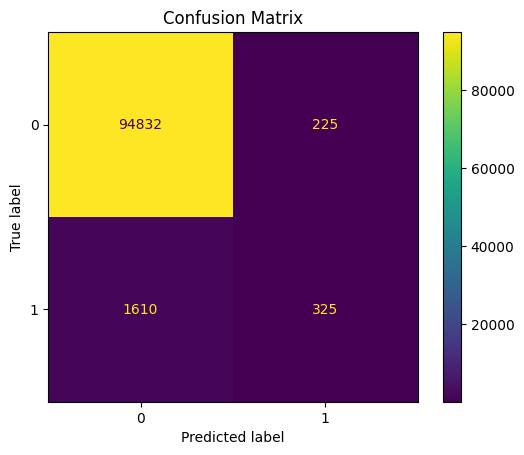

In [32]:
cm = confusion_matrix(y_test, smote_y_pred)
display = ConfusionMatrixDisplay(confusion_matrix=cm)
display.plot()
plt.title('Confusion Matrix')
plt.show()

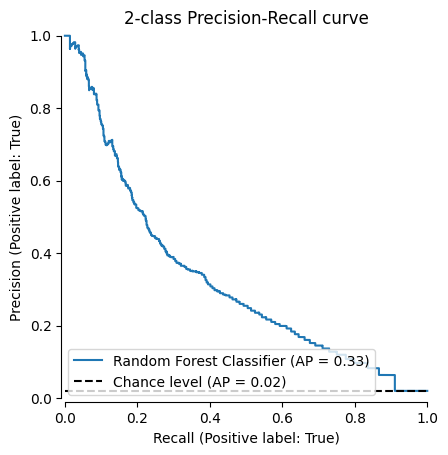

In [33]:
display = PrecisionRecallDisplay.from_estimator(
    clf, X_test, y_test, name="Random Forest Classifier", plot_chance_level=True, despine=True
)
_ = display.ax_.set_title("2-class Precision-Recall curve")